In [ ]:
from Matrix_graph import ws_opinion_graph, create_matrix_rep, GraphState, add_media_nodes, add_disinfo_nodes
from Matrix_simuleringslogik import time_step_no_media_no_disinfo, simpel_simulering, data_processing
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
TestGraf =  ws_opinion_graph(1000,10,0.1,seed = 11)

In [ ]:
MatrixGraf = create_matrix_rep(TestGraf)

In [ ]:
MatrixGraf.opinions, no_media_no_disinfo_sim_results,no_media_no_disinfo_startcond,no_media_no_disinfo_endcond= simpel_simulering(MatrixGraf,1000)

In [ ]:
Masktest = MatrixGraf.type == 'Human'

In [ ]:
average_opinionresult, average_distance_to_the_mean_result = data_processing(no_media_no_disinfo_sim_results,Masktest)

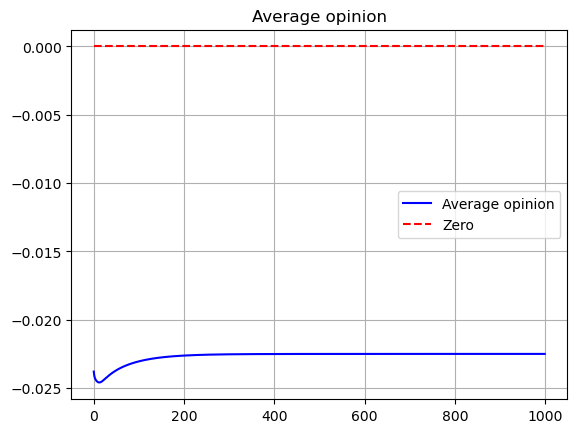

In [ ]:
plt.figure()
plt.plot(np.arange(len(average_opinionresult)),average_opinionresult,'b-',label = 'Average opinion')
plt.plot(np.arange(len(average_opinionresult)),np.zeros(len(average_opinionresult)),'r--',label = 'Zero')
plt.legend()
plt.grid()
plt.title('Average opinion')
plt.show()

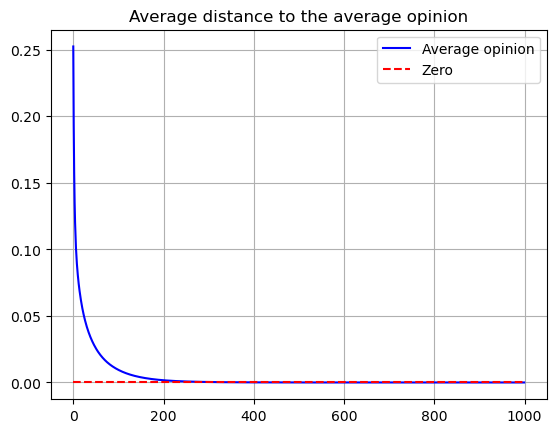

In [ ]:
plt.figure()
plt.plot(np.arange(len(average_distance_to_the_mean_result)),average_distance_to_the_mean_result,'b-',label = 'Average opinion')
plt.plot(np.arange(len(average_distance_to_the_mean_result)),np.zeros(len(average_opinionresult)),'r--',label = 'Zero')
plt.legend()
plt.grid()
plt.title('Average distance to the average opinion')
plt.show()

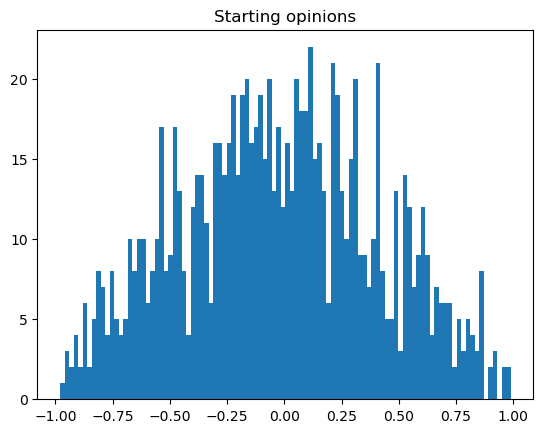

In [ ]:
plt.figure()
plt.hist(no_media_no_disinfo_startcond,bins =100)
plt.title('Starting opinions')
plt.show()

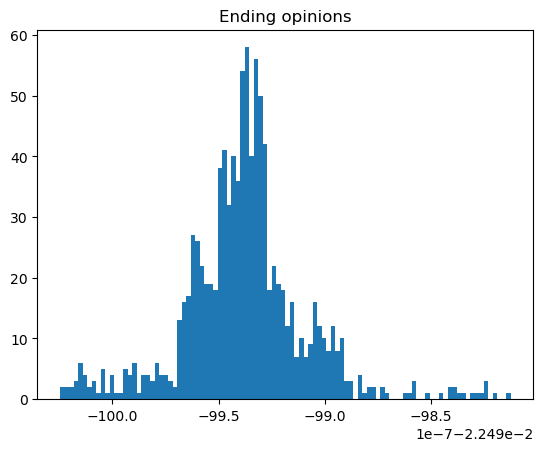

Max =  -0.022499812153123182
Min =  -0.02250002472479923
|Diff| =  2.125716760496832e-07


In [ ]:
plt.figure()
plt.hist(no_media_no_disinfo_endcond,bins =100)
plt.title('Ending opinions')
plt.show()
print('Max = ',max(no_media_no_disinfo_endcond))
print('Min = ',min(no_media_no_disinfo_endcond))
print('|Diff| = ', abs(max(no_media_no_disinfo_endcond)-min(no_media_no_disinfo_endcond)))

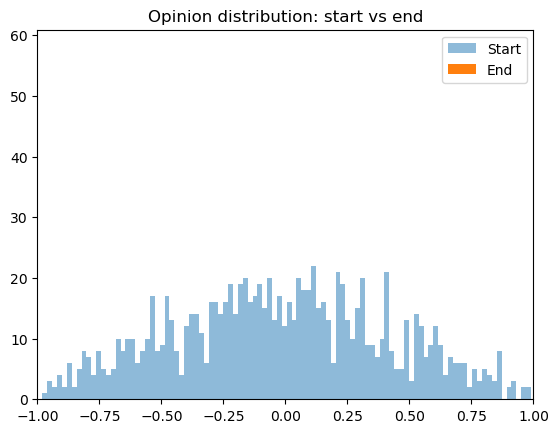

In [ ]:
plt.figure()
plt.hist(no_media_no_disinfo_startcond, bins=100, alpha=0.5, label='Start')
plt.hist(no_media_no_disinfo_endcond, bins=100, alpha=1, label='End')
plt.xlim(-1, 1)
plt.legend()
plt.title('Opinion distribution: start vs end')
plt.show()

In [ ]:
medmedia = add_media_nodes(MatrixGraf,1,0.2,11)

In [ ]:
medmedia.matrix


array([[0.  , 0.42, 0.91, ..., 0.67, 0.59, 0.  ],
       [0.76, 0.  , 0.34, ..., 0.31, 0.56, 0.  ],
       [0.59, 0.77, 0.  , ..., 0.49, 0.11, 0.  ],
       ...,
       [0.27, 0.44, 0.09, ..., 0.  , 0.95, 0.  ],
       [0.65, 0.36, 0.65, ..., 0.96, 0.  , 0.  ],
       [0.  , 0.  , 0.  , ..., 0.  , 0.24, 0.  ]], shape=(1001, 1001))

In [ ]:
mask = medmedia.type == "Media"
print(mask)

[False False False ... False False  True]


In [ ]:
mediareturn  = medmedia.matrix[mask]
print(mediareturn)

[[0.   0.   0.   ... 0.   0.24 0.  ]]


In [ ]:
medmedia.opinions[mask]

array([0.24])

In [ ]:
weight_sum = medmedia.matrix.sum(axis=0)

weighted_neighbour_opinion_sum = medmedia.matrix.T @ medmedia.opinions
avg_neighbour_opinion = np.divide(weighted_neighbour_opinion_sum,
                                      weight_sum, out=np.zeros_like(weighted_neighbour_opinion_sum),
                                      where=weight_sum != 0)
new_opinions = medmedia.opinions + medmedia.learningrate * (avg_neighbour_opinion - medmedia.opinions)

In [ ]:
print(new_opinions)

[-0.02249993 -0.02249993 -0.02249993 ... -0.02249993 -0.02035877
  0.24      ]


In [ ]:
testresult ,_,_,_ = simpel_simulering(medmedia,300)

In [ ]:
print(testresult)

[0.15582304 0.15418077 0.15534546 ... 0.15537005 0.15731517 0.24      ]


In [ ]:
medmedia.opinions, media_no_disinfo_sim_results,media_no_disinfo_startcond,media_no_disinfo_endcond= simpel_simulering(medmedia,1500)

In [ ]:
print(medmedia.opinions)

[0.23903333 0.23901444 0.23902779 ... 0.23902815 0.23905051 0.24      ]


In [ ]:
maskmedmedia =medmedia.type == 'Human'

In [ ]:
media_average_opinionresult, media_average_distance_to_the_mean_result = data_processing(media_no_disinfo_sim_results,maskmedmedia)

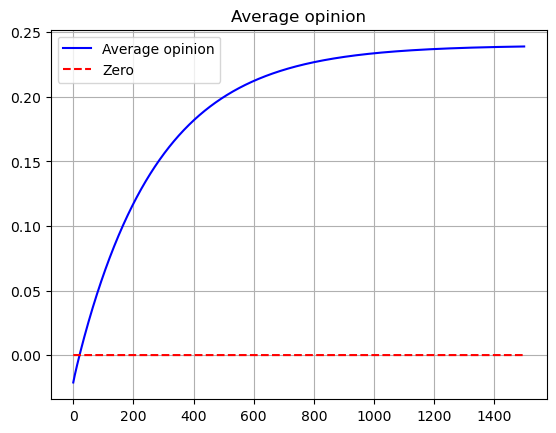

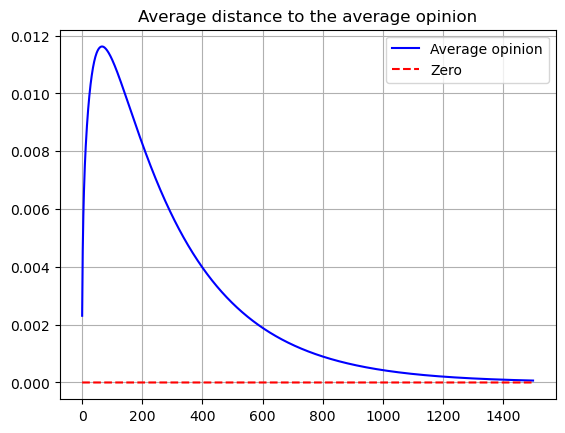

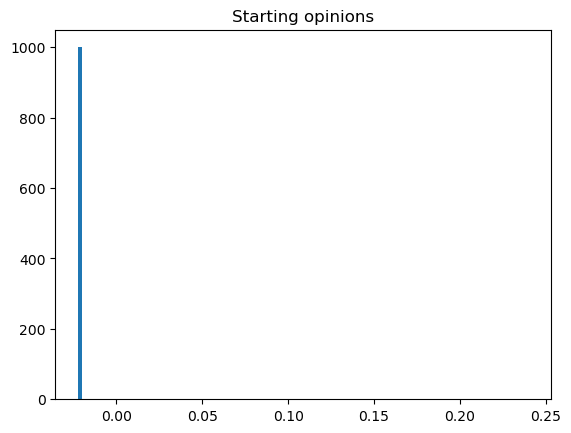

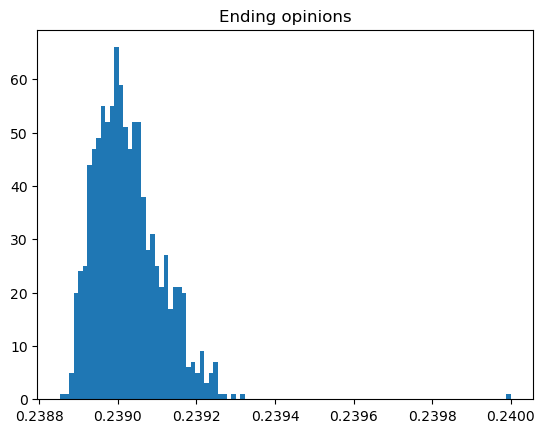

Max =  0.24
Min =  0.2388531225324192
|Diff| =  0.001146877467580798


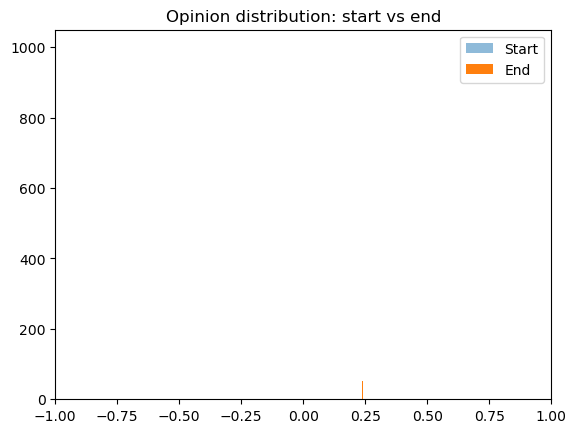

In [ ]:
plt.figure()
plt.plot(np.arange(len(media_average_opinionresult)),media_average_opinionresult,'b-',label = 'Average opinion')
plt.plot(np.arange(len(media_average_opinionresult)),np.zeros(len(media_average_opinionresult)),'r--',label = 'Zero')
plt.legend()
plt.grid()
plt.title('Average opinion')
plt.show()

plt.figure()
plt.plot(np.arange(len(media_average_distance_to_the_mean_result)),media_average_distance_to_the_mean_result,'b-',label = 'Average opinion')
plt.plot(np.arange(len(media_average_distance_to_the_mean_result)),np.zeros(len(media_average_distance_to_the_mean_result)),'r--',label = 'Zero')
plt.legend()
plt.grid()
plt.title('Average distance to the average opinion')
plt.show()

plt.figure()
plt.hist(media_no_disinfo_startcond,bins =100)
plt.title('Starting opinions')
plt.show()

plt.figure()
plt.hist(media_no_disinfo_endcond,bins =100)
plt.title('Ending opinions')
plt.show()
print('Max = ',max(media_no_disinfo_endcond))
print('Min = ',min(media_no_disinfo_endcond))
print('|Diff| = ', abs(max(media_no_disinfo_endcond)-min(media_no_disinfo_endcond)))

plt.figure()
plt.hist(media_no_disinfo_startcond, bins=100, alpha=0.5, label='Start')
plt.hist(media_no_disinfo_endcond, bins=100, alpha=1, label='End')
plt.xlim(-1, 1)
plt.legend()
plt.title('Opinion distribution: start vs end')
plt.show()

In [ ]:
meddisinfo = add_disinfo_nodes(medmedia,1,0.2,11)

In [ ]:
maskmeddisinfo = meddisinfo.type == 'Human'

In [ ]:
maskmeddisinfo.shape

(1002,)

In [ ]:
medmedia.opinions, media_disinfo_sim_results,media_disinfo_startcond,media_disinfo_endcond= simpel_simulering(meddisinfo,1500)

In [ ]:
media_disinfo_average_opinionresult, media_disinfo_average_distance_to_the_mean_result = data_processing(media_disinfo_sim_results,maskmeddisinfo)

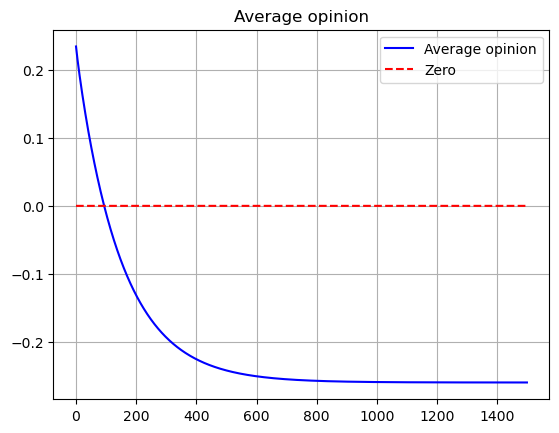

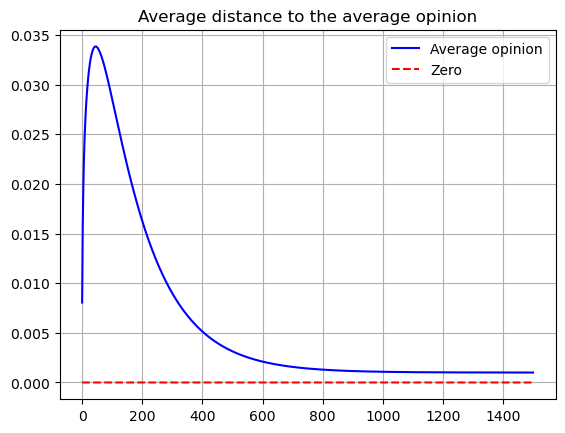

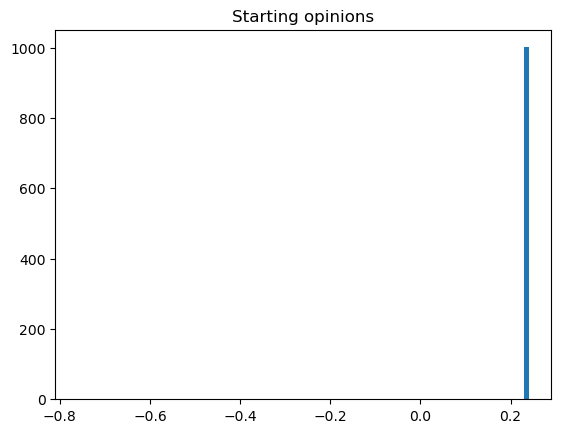

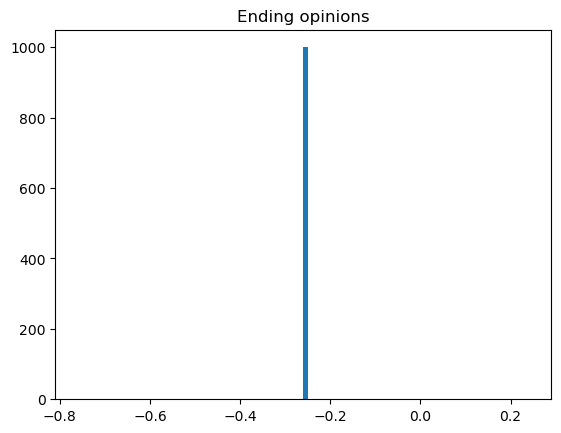

Max =  0.24
Min =  -0.76
|Diff| =  1.0


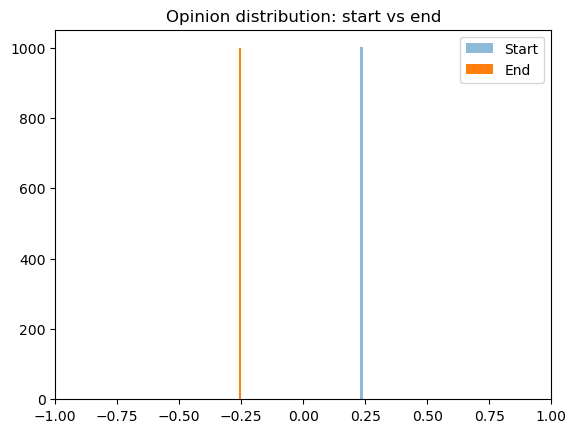

In [ ]:
plt.figure()
plt.plot(np.arange(len(media_disinfo_average_opinionresult)),media_disinfo_average_opinionresult,'b-',label = 'Average opinion')
plt.plot(np.arange(len(media_disinfo_average_opinionresult)),np.zeros(len(media_disinfo_average_opinionresult)),'r--',label = 'Zero')
plt.legend()
plt.grid()
plt.title('Average opinion')
plt.show()

plt.figure()
plt.plot(np.arange(len(media_disinfo_average_distance_to_the_mean_result)),media_disinfo_average_distance_to_the_mean_result,'b-',label = 'Average opinion')
plt.plot(np.arange(len(media_disinfo_average_distance_to_the_mean_result)),np.zeros(len(media_disinfo_average_distance_to_the_mean_result)),'r--',label = 'Zero')
plt.legend()
plt.grid()
plt.title('Average distance to the average opinion')
plt.show()

plt.figure()
plt.hist(media_disinfo_startcond,bins =100)
plt.title('Starting opinions')
plt.show()

plt.figure()
plt.hist(media_disinfo_endcond,bins =100)
plt.title('Ending opinions')
plt.show()
print('Max = ',max(media_disinfo_endcond))
print('Min = ',min(media_disinfo_endcond))
print('|Diff| = ', abs(max(media_disinfo_endcond)-min(media_disinfo_endcond)))

plt.figure()
plt.hist(media_disinfo_startcond, bins=100, alpha=0.5, label='Start')
plt.hist(media_disinfo_endcond, bins=100, alpha=1, label='End')
plt.xlim(-1, 1)
plt.legend()
plt.title('Opinion distribution: start vs end')
plt.show()

In [ ]:
print(average_opinionresult.shape)
print(media_average_opinionresult.shape)
print(media_disinfo_average_opinionresult.shape)

(1000,)
(1500,)
(1500,)


In [ ]:
total = np.concatenate((average_opinionresult,media_average_opinionresult,media_disinfo_average_opinionresult))
disttotal = np.concatenate((average_distance_to_the_mean_result,media_average_distance_to_the_mean_result,media_disinfo_average_distance_to_the_mean_result))

In [ ]:
total.shape

(4000,)

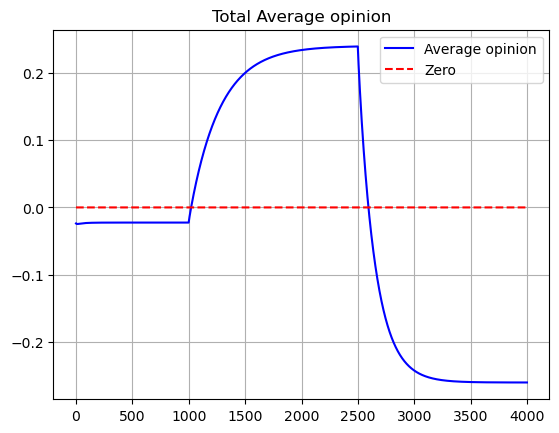

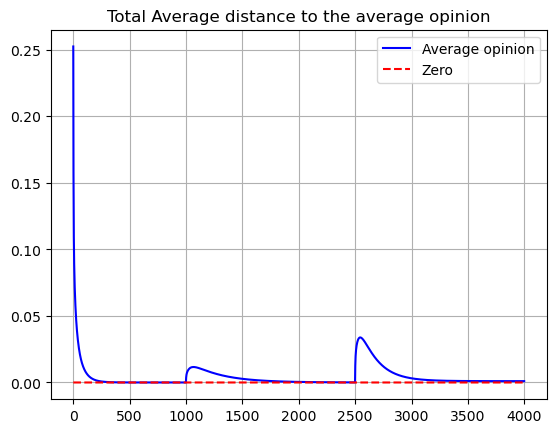

In [ ]:
plt.figure()
plt.plot(np.arange(len(total)),total,'b-',label = 'Average opinion')
plt.plot(np.arange(len(total)),np.zeros(len(total)),'r--',label = 'Zero')
plt.legend()
plt.grid()
plt.title('Total Average opinion')
plt.show()


plt.figure()
plt.plot(np.arange(len(disttotal)),disttotal,'b-',label = 'Average opinion')
plt.plot(np.arange(len(disttotal)),np.zeros(len(disttotal)),'r--',label = 'Zero')
plt.legend()
plt.grid()
plt.title('Total Average distance to the average opinion')
plt.show()

In [ ]:
senarie1maskmedia = meddisinfo.type == 'Media'
senarie1maskdisinfo = meddisinfo.type == 'Disinformation'

In [ ]:
meddisinfo.opinions[senarie1maskmedia]

array([0.24])

In [ ]:
meddisinfo.opinions[senarie1maskdisinfo]

array([-0.76])

In [ ]:
abs (meddisinfo.opinions[senarie1maskmedia] -meddisinfo.opinions[senarie1maskdisinfo])

array([1.])

In [ ]:
Hovedtest = ws_opinion_graph(10000,150,seed = 200)


In [ ]:
Hovedtestmatrix = create_matrix_rep(Hovedtest)

In [ ]:
MedierHoved = add_media_nodes(Hovedtestmatrix,100,seed = 200)

In [ ]:
DisinfoHoved = add_disinfo_nodes(MedierHoved,100,seed = 200)

In [ ]:
maskmediahoved = DisinfoHoved.type == "Media"
maskdisinfohoved = DisinfoHoved.type == "Disinformation"


In [ ]:
print(DisinfoHoved.opinions[maskmediahoved])
print(DisinfoHoved.opinions[maskmediahoved].mean())
print(DisinfoHoved.opinions[maskmediahoved].shape)


[0.59 0.58 0.41 0.65 0.5  0.74 0.43 0.68 0.43 0.91 0.18 0.11 0.79 0.67
 0.32 0.49 0.6  0.42 0.6  0.35 0.33 0.28 0.36 0.38 0.8  0.63 0.36 0.07
 0.17 0.63 0.9  0.76 0.73 0.58 0.33 0.5  0.34 0.62 0.42 0.69 0.66 0.86
 0.3  0.6  0.63 0.47 0.65 0.72 0.62 0.33 0.43 0.74 0.11 0.13 0.72 0.95
 0.46 0.87 0.27 0.66 0.55 0.06 0.26 0.38 0.28 0.35 0.36 0.09 0.54 0.58
 0.76 0.56 0.55 0.41 0.77 0.35 0.66 0.83 0.07 0.74 0.33 0.34 0.38 0.39
 0.6  0.52 0.51 0.57 0.42 0.46 0.47 0.41 0.32 0.57 0.44 0.46 0.74 0.56
 0.69 0.52]
0.5036
(100,)


In [ ]:
print(DisinfoHoved.opinions[maskdisinfohoved])
print(DisinfoHoved.opinions[maskdisinfohoved].mean())

[-0.41 -0.43 -0.32 -0.37 -0.56 -0.12 -0.74 -0.64 -0.11 -0.8  -0.36 -0.91
 -0.38 -0.11 -0.33 -0.64 -0.69 -0.44 -0.2  -0.9  -0.55 -0.46 -0.76 -0.84
 -0.81 -0.83 -0.44 -0.35 -0.34 -0.67 -0.24 -0.82 -0.68 -0.88 -0.55 -0.53
 -0.67 -0.42 -0.65 -0.51 -0.35 -0.57 -0.29 -0.1  -0.46 -0.56 -0.6  -0.65
 -0.63 -0.68 -0.7  -0.38 -0.38 -0.74 -0.66 -0.28 -0.24 -0.76 -0.22 -0.34
 -0.63 -0.97 -0.04 -0.37 -0.45 -0.53 -0.46 -0.52 -0.46 -0.34 -0.78 -0.82
 -0.17 -0.41 -0.42 -0.7  -0.46 -0.39 -0.63 -0.4  -0.19 -0.44 -0.14 -0.25
 -0.51 -0.55 -0.78 -0.71 -0.41 -0.61 -0.07 -0.72 -0.75 -0.24 -0.39 -0.29
 -0.78 -0.5  -0.39 -0.59]
-0.5031


In [ ]:
DisinfoHoved.opinions, hoved_sim_results,hoved_startcond,hoved_endcond= simpel_simulering(DisinfoHoved,200)

In [ ]:
maskhumanhoved = DisinfoHoved.type == "Human"


In [ ]:
Hoved_average_opinionresult, Hoved_average_distance_to_the_mean_result = data_processing(hoved_sim_results,maskhumanhoved)

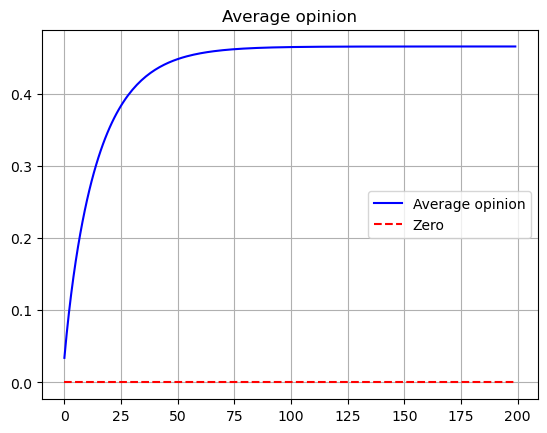

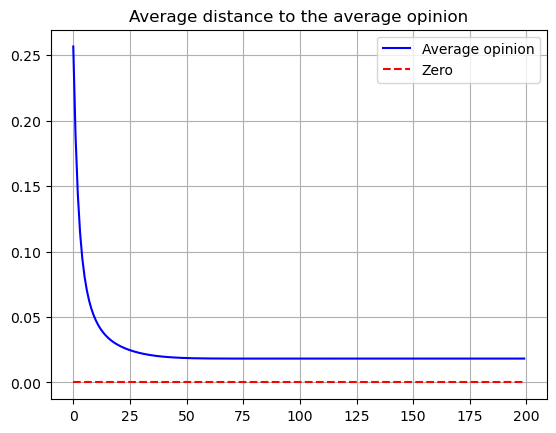

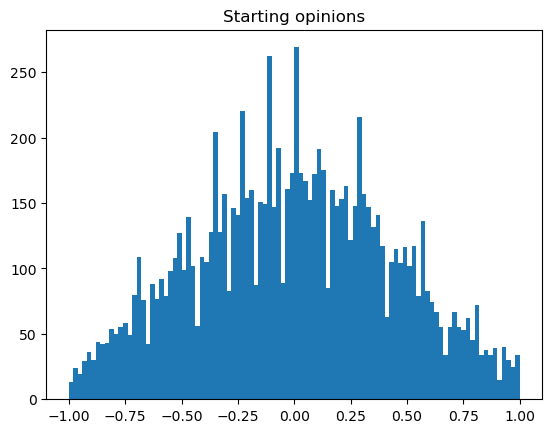

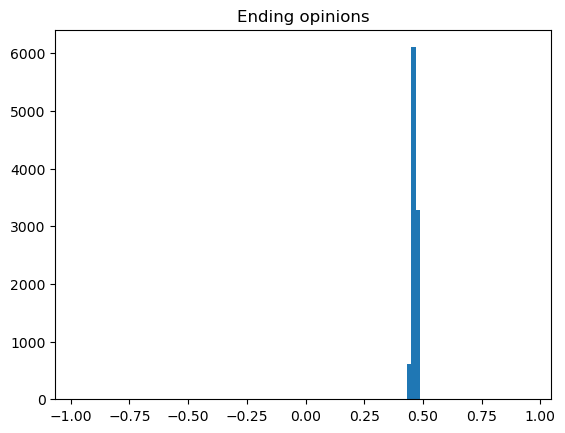

Max =  0.95
Min =  -0.97
|Diff| =  1.92


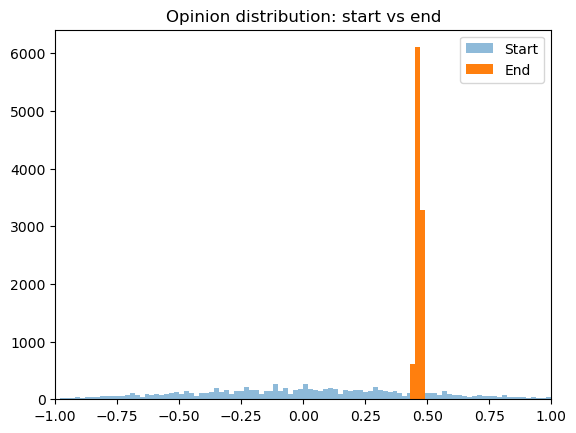

In [ ]:
plt.figure()
plt.plot(np.arange(len(Hoved_average_opinionresult)),Hoved_average_opinionresult,'b-',label = 'Average opinion')
plt.plot(np.arange(len(Hoved_average_opinionresult)),np.zeros(len(Hoved_average_opinionresult)),'r--',label = 'Zero')
plt.legend()
plt.grid()
plt.title('Average opinion')
plt.show()

plt.figure()
plt.plot(np.arange(len(Hoved_average_distance_to_the_mean_result)),Hoved_average_distance_to_the_mean_result,'b-',label = 'Average opinion')
plt.plot(np.arange(len(Hoved_average_distance_to_the_mean_result)),np.zeros(len(Hoved_average_distance_to_the_mean_result)),'r--',label = 'Zero')
plt.legend()
plt.grid()
plt.title('Average distance to the average opinion')
plt.show()

plt.figure()
plt.hist(hoved_startcond,bins =100)
plt.title('Starting opinions')
plt.show()

plt.figure()
plt.hist(hoved_endcond,bins =100)
plt.title('Ending opinions')
plt.show()
print('Max = ',max(hoved_endcond))
print('Min = ',min(hoved_endcond))
print('|Diff| = ', abs(max(hoved_endcond)-min(hoved_endcond)))

plt.figure()
plt.hist(hoved_startcond, bins=100, alpha=0.5, label='Start')
plt.hist(hoved_endcond, bins=100, alpha=1, label='End')
plt.xlim(-1, 1)
plt.legend()
plt.title('Opinion distribution: start vs end')
plt.show()

In [ ]:
sum(DisinfoHoved.type == "Human")

np.int64(10000)

In [ ]:
sum(DisinfoHoved.type == "Media")

np.int64(100)

In [ ]:
sum(DisinfoHoved.type == "Disinformation")

np.int64(100)